Observational sample size: 200
Observational sample size: 500
Observational sample size: 1000
Observational sample size: 2000
   obs_sample_size      mean       std
0              200  1.690933  0.597261
1              500  1.645701  0.547256
2             1000  1.651715  0.451566
3             2000  1.660380  0.443282


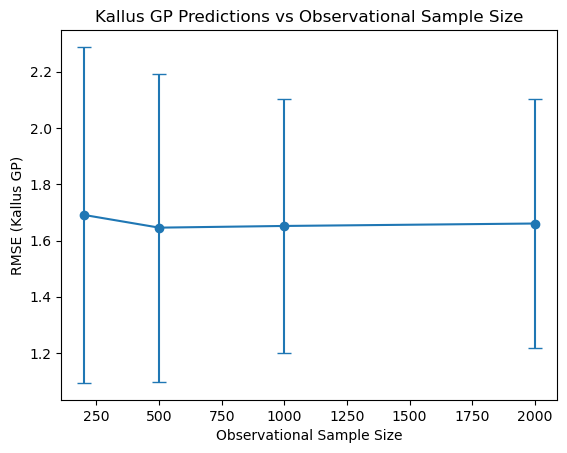

In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
import copy
import GPy
import matplotlib.pyplot as plt

# -------------------------------
# Helper functions
# -------------------------------
rmse = lambda x, y: np.sqrt(mean_squared_error(x, y))

linear_reg_parameter_pairs = [
    (Ridge(), {'alpha': np.logspace(-7, 7, 8), 'tol': [1e-3]})
]

def get_best_model_from_gridcv(X, Y, reg_parameter_pairs):
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
    best_model = None
    min_err = np.inf

    for reg, params in reg_parameter_pairs:
        model = GridSearchCV(reg, params, cv=2, refit=True, n_jobs=-1)
        model.fit(X, Y)
        val_err = rmse(y_test, model.predict(x_test))
        if val_err < min_err:
            min_err = val_err
            best_model = copy.deepcopy(model.best_estimator_)
    return best_model

def run_kallus_model(X_rct, Y_rct, T_rct, X_obs, Y_obs, T_obs, X_eval):
    # GP on observational data
    kern0 = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    kern1 = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
    
    f0_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==0]), np.vstack(Y_obs[T_obs==0]), kern0)
    f0_gp.optimize()
    
    f1_gp = GPy.models.GPRegression(np.vstack(X_obs[T_obs==1]), np.vstack(Y_obs[T_obs==1]), kern1)
    f1_gp.optimize()
    
    omega_rct_pred = f1_gp.predict(np.vstack(X_rct))[0] - f0_gp.predict(np.vstack(X_rct))[0]
    omega_eval_pred = f1_gp.predict(np.vstack(X_eval))[0] - f0_gp.predict(np.vstack(X_eval))[0]
    
    _mean_outcome = np.mean(Y_obs)
    
    def ite_adjusted_outcome(Y, T, propensity, c=_mean_outcome):
        _ite = np.zeros(Y.shape)
        _ite[T==1] = (Y[T==1] - c)/propensity
        _ite[T==0] = -(Y[T==0] - c)/(1-propensity)
        return _ite
    
    prop_rct = np.mean(T_rct)
    eta_rct_est = np.vstack(ite_adjusted_outcome(Y_rct, T_rct, prop_rct)) - np.vstack(omega_rct_pred)
    
    best_linear = get_best_model_from_gridcv(X_rct.reshape(-1,1), eta_rct_est, linear_reg_parameter_pairs)
    
    return best_linear, omega_eval_pred

# -------------------------------
# Load your data
# -------------------------------
data_path = "/Users/evangelosdimitriou/myGitRepo/CausalICM/rebuttals/diff_sample_size_data.csv"
df = pd.read_csv(data_path)

# Test grid for CATE predictions
test_data = np.round(np.arange(-2.0, 2.04, 0.04), 2)
trueCATE = 1 + test_data + test_data**2

# Observational sample sizes to explore
obs_sample_sizes = sorted(df['obs_sample_size'].unique())
n_iterations = 1  # since we use existing datasets, we can loop over datasetNo if needed

results_all = []

# -------------------------------
# Main loop
# -------------------------------
for obs_n in obs_sample_sizes:
    print(f"Observational sample size: {obs_n}")
    
    df_obs_n = df[df['obs_sample_size'] == obs_n]
    dataset_ids = df_obs_n['datasetNo'].unique()
    
    for ds in dataset_ids:
        df_subset = df_obs_n[df_obs_n['datasetNo'] == ds]
        
        # Split RCT and observational
        df_rct = df_subset[df_subset['S'] == 1]
        df_obs = df_subset[df_subset['S'] == 0]
        
        X_rct, Y_rct, T_rct = df_rct['X'].values, df_rct['Y'].values, df_rct['A'].values
        X_obs, Y_obs, T_obs = df_obs['X'].values, df_obs['Y'].values, df_obs['A'].values
        
        # Run Kallus GP
        kallus_model, omega_eval_pred = run_kallus_model(
            X_rct, Y_rct, T_rct, X_obs, Y_obs, T_obs, test_data
        )
        tau_pred = kallus_model.predict(test_data.reshape(-1,1)) + omega_eval_pred
        
        # RMSE for this dataset
        rmse_val = rmse(tau_pred, trueCATE)
        
        results_all.append({
            'obs_sample_size': obs_n,
            'datasetNo': ds,
            'rmse': rmse_val
        })

# -------------------------------
# Convert to DataFrame and summarize
# -------------------------------
results_df = pd.DataFrame(results_all)
summary_df = results_df.groupby('obs_sample_size')['rmse'].agg(['mean', 'std']).reset_index()
print(summary_df)

# Optional: plot
plt.errorbar(summary_df['obs_sample_size'], summary_df['mean'], yerr=summary_df['std'], fmt='o-', capsize=5)
plt.xlabel("Observational Sample Size")
plt.ylabel("RMSE (Kallus GP)")
plt.title("Kallus GP Predictions vs Observational Sample Size")
plt.show()

In [2]:
# -------------------------------
# Save results to CSV
# -------------------------------
results_df.to_csv("sample_size_imbalance_kallusGP.csv", index=False)
print("Results saved to sample_size_imbalance_kallusGP.csv")

Results saved to sample_size_imbalance_kallusGP.csv


In [3]:
# --------------------------------
# Mean and SD of RMSE by obs size
# --------------------------------
summary_df = (
    results_df
    .groupby("obs_sample_size")["rmse"]
    .agg(mean_RMSE="mean", sd_RMSE="std", n="count")
    .reset_index()
    .sort_values("obs_sample_size")
)

print("\nMean and SD of RMSE by observational sample size:\n")
print(summary_df)

# Optional: nicer formatting
print("\nFormatted output:\n")
for _, row in summary_df.iterrows():
    print(f"Obs size {int(row['obs_sample_size'])}: "
          f"Mean RMSE = {row['mean_RMSE']:.4f}, "
          f"SD = {row['sd_RMSE']:.4f}, "
          f"(n={int(row['n'])})")


Mean and SD of RMSE by observational sample size:

   obs_sample_size  mean_RMSE   sd_RMSE   n
0              200   1.690933  0.597261  50
1              500   1.645701  0.547256  50
2             1000   1.651715  0.451566  50
3             2000   1.660380  0.443282  50

Formatted output:

Obs size 200: Mean RMSE = 1.6909, SD = 0.5973, (n=50)
Obs size 500: Mean RMSE = 1.6457, SD = 0.5473, (n=50)
Obs size 1000: Mean RMSE = 1.6517, SD = 0.4516, (n=50)
Obs size 2000: Mean RMSE = 1.6604, SD = 0.4433, (n=50)
